# MicroDuck 全向行走强化学习：零基础实践

**版本：** v2.4 · **预计时长：** ~70 min（基础讲解 ~35 min + GPU 实践 ~15 min + 对比分析）

> 本教程不要求强化学习或机器人基础。先建立直觉，再运行代码；数学公式只用于说明关键概念。

---

## A. 我们要解决什么问题？

给 MicroDuck 一个期望速度，例如“向前 0.3 m/s、向左 0.1 m/s、同时逆时针转动”，让它自动决定每个时刻 14 个关节应该如何运动，并且做到：

- 尽量准确地跟随前后、左右和转向命令；
- 保持直立，减少摔倒和打滑；
- 动作连续、步态自然，不频繁撞击自身或触碰关节极限；
- 面对传感器误差、执行延迟、质量变化和外部推力时仍能行走。

手工为 14 个关节编写覆盖所有速度组合的控制规则很困难。**强化学习（Reinforcement Learning, RL）**让机器人在仿真中反复尝试动作，根据奖励判断结果好坏，并逐渐学出一套从观测到动作的控制策略。

### 这节课学完后，你应该能回答

1. 什么是强化学习，为什么机器人控制会使用它？
2. MDP、观测、动作、奖励、策略、episode 分别是什么？
3. 常见 RL 算法有哪些？为什么本实验选择 PPO？
4. MicroDuck 的奖励函数如何同时表达“走得准、站得稳、动作合理”？
5. 域随机化如何帮助仿真策略适应真实世界的不确定性？
6. ROCm、PyTorch、UniLab、`microduck_rl_unilab` 和本 lab 分别负责什么？
7. 如何训练、回放并判断一个步态策略是否正在改善？

### 三阶段实践

| 阶段 | 配置 | 你要做什么 | 预计时间 |
|---|---|---|---|
| **冒烟测试** | 4 env × 2 iter | 查看完整日志，确认整条链路可运行 | ~1 min |
| **一** | 500 env × 300 iter | 从零训练并生成 **10 秒**回放 | ~5 + 2 min |
| **二** | 2048 env × 500 iter | 回放仓库内置 demo checkpoint | ~2 min |
| **三** | 对比分析 | 比较 reward、episode length、曲线和视频 | ~10 min |

**选做：** 从 demo checkpoint 继续训练 +500 iter（2048 env，~10 min）。

> ⚠️ **不要 Run All。** 请按顺序逐 cell 运行；长训练 cell 数分钟处于 `[*]` 是正常现象。

## B. 软件栈与环境自检

### B1 各组件是什么关系？

```text
┌─────────────────────────────────────────────────────────────────────┐
│ microduck_rl_lab（本教程）                                          │
│ Notebook、运行脚本、预训练 checkpoint、实验说明                     │
└──────────────────────────────┬──────────────────────────────────────┘
                               │ 调用
┌──────────────────────────────▼──────────────────────────────────────┐
│ microduck_rl_unilab（MicroDuck 任务包）                             │
│ 机器人 XML/资产、观测与动作定义、奖励函数、域随机化、PPO 任务配置    │
└──────────────────────────────┬──────────────────────────────────────┘
                               │ 注册任务到
┌──────────────────────────────▼──────────────────────────────────────┐
│ UniLab（通用机器人学习框架）                                        │
│ 创建并行环境、连接 MuJoCo、采样数据、运行 PPO、保存日志/checkpoint   │
└───────────────┬───────────────────────────────────┬─────────────────┘
                │ 仿真                              │ 神经网络训练
        ┌───────▼────────┐                 ┌────────▼────────┐
        │ MuJoCo          │                 │ PyTorch          │
        │ 动力学/碰撞/传感器│                 │ 张量/自动求导/PPO │
        └────────────────┘                 └────────┬────────┘
                                                   │ AMD GPU 后端
                                          ┌────────▼──────────────┐
                                          │ ROCm / HIP             │
                                          │ 支持的 AMD GPU 计算栈   │
                                          └───────────────────────┘
```

容易混淆的几点：

- **ROCm 不是强化学习框架**：它让 PyTorch 能在 AMD GPU 上计算。
- **PyTorch 不包含 MicroDuck 任务**：它负责神经网络和优化。
- **UniLab 不等于机器人模型**：它提供通用训练与仿真管理能力。
- **`microduck_rl_unilab` 才定义本实验的机器人、奖励与任务配置。**
- **`microduck_rl_lab` 是教学层**：不重新实现 PPO，只组织实验并提供 notebook。
- 本实验选择 `--sim mujoco`；MuJoCo 计算机器人动力学，PyTorch/ROCm 执行策略网络和 PPO 更新，两者职责不同。

### B2 容器内位置

| 组件 | 形态 | 位置或版本 |
|---|---|---|
| ROCm + PyTorch | 基础镜像 | ROCm 后端的 torch 2.11.0 |
| UniLab | Python 包 | `unilab[mujoco]==1.0.0` |
| `microduck_rl_unilab` | git clone | `/opt/microduck_rl_unilab`（训练工作目录） |
| 本 lab | 主机挂载 | `/workspace/microduck_rl_lab` |
| 阶段二 demo | 本 lab 内置 | `examples/velocity_flat_demo/` |

入口脚本已经设置任务注册所需的 `UNILAB_EXTRA_REGISTRY_PACKAGES` 和 `MICRODUCK_ROOT`。运行下面的自检，重点确认 **HIP available**、任务可注册，以及 checkpoint 存在。

### B3 硬件兼容性与参考性能

本 lab 不限定 MI210。只要当前 ROCm、PyTorch 和容器设备映射支持目标 GPU，原则上也可在 MI300X 等 AMD Instinct GPU，以及受对应 ROCm 版本支持的 Radeon GPU 上运行。不同型号的显存容量、架构支持和吞吐量不同，应以自检结果为准，并按显存适当调整 `num_envs`。

下表时间是**本教程在单张 MI210 上的实测参考值**，不是硬件要求；换用其他 GPU 时训练时长和可承载的并行环境数会变化。

| | 阶段一 | 阶段二 demo |
|---|---|---|
| 配置 | **500 × 300** | **2048 × 500** |
| 每 iter 样本 | 500×24 = 12,000 | 2048×24 = 49,152 |
| 总 env steps | ~3.6M | ~24.6M |
| 训练墙钟 | ~5 min | ~10 min |
| Final reward | 中等（受随机种子影响） | **~94** |
| Episode length | 通常 < 500 | **~888 / 1000** |

`2048 env` 不表示每个 iteration 更快；它表示一次并行收集更多经验。策略接口为：Actor 观测 **61 维**、Critic 观测 **76 维**、动作 **14 维**。

In [1]:
!bash /workspace/microduck_rl_lab/scripts/check_env.sh

=== MicroDuck RL Lab environment ===
LAB_ROOT=/workspace/microduck_rl_lab
MICRODUCK_ROOT=/opt/microduck_rl_unilab
UNILAB_EXTRA_REGISTRY_PACKAGES=microduck_rl_unilab.tasks

Python          3.12.3
PyTorch         2.11.0+rocm7.14.1
HIP (ROCm)      7.14.60850
CUDA available  True
GPU count       1
GPU 0           AMD Instinct MI210
unilab             1.0.0
unilab-rl          1.0.0
unisim-core        1.0.0
microduck_rl_unilab 0.1.0

microduck_rl_unilab commit:
  8530dbc0ea0b22718c2266c3cb89f2077fa37912 Merge pull request #1 from alexhegit/feat/mirror-loss-turn-in-place

Contract (deploy_contract.py): actor=61 critic=76 action=14
=== OK ===


## C. 强化学习与 MDP：先理解一次交互

### C1 什么是强化学习？

强化学习研究的是：**智能体（agent）在环境中采取动作，根据反馈改进长期行为。** 它和监督学习的区别是，训练数据通常没有“这个状态下 14 个关节的标准答案”；只有动作之后得到的奖励。机器人必须通过大量试错发现哪些动作序列更好。

```text
                 ┌──────────── 奖励 rₜ、下一状态 sₜ₊₁ ────────────┐
                 │                                               │
环境 / MicroDuck ├─ 观测 oₜ ─→ 策略 πθ（神经网络）─→ 动作 aₜ ───┤
   MuJoCo        │                                               │
                 └──────────── 重复直到摔倒或超时 ────────────────┘
```

为什么机器人任务适合使用 RL？

- 关节之间强耦合，一个动作的效果会持续影响后续状态；
- 目标不止一个：速度、平衡、平滑、能耗和安全需要共同权衡；
- 仿真可以并行产生数百万次交互，成本远低于真机试错；
- 神经网络策略能学习难以手写的非线性反馈控制规律。

但 RL 不是万能方案：奖励设计不当会“钻空子”，仿真和真机存在差距，训练结果也有随机性。因此需要回放、指标检查、域随机化和最终真机安全验证。

### C2 MDP 是什么？

强化学习通常用 **马尔可夫决策过程（Markov Decision Process, MDP）**描述。MDP 常写成 `(S, A, P, R, γ)`：

| 符号 | 含义 | MicroDuck 中的例子 |
|---|---|---|
| `S` 状态 | 环境真实情况 | 姿态、关节、速度、接触状态等 |
| `A` 动作 | 智能体可做的决策 | 14 维关节目标 |
| `P` 转移 | 动作如何导致下一状态 | MuJoCo 动力学、碰撞和执行器模型 |
| `R` 奖励 | 当前结果有多好 | 跟踪速度、直立、步态等奖励之和 |
| `γ` 折扣 | 多重视未来奖励 | 越接近 1，越重视长期稳定表现 |

**马尔可夫性**的直觉是：给定当前状态和动作，预测下一步不必再依赖完整历史。真实机器人通常只能看到带噪声、延迟且不完整的观测 `oₜ`，所以代码中会区分“状态”和“观测”。

### C3 映射到本任务

- **命令**：每隔一段时间采样 `twist = (vx, vy, yaw_rate)`；范围约为前后 `±0.4 m/s`、横向 `±0.3 m/s`、转向 `±1.0 rad/s`。
- **观测**：身体角速度、重力方向、关节位置/速度、上一动作、速度命令和头部命令等；Actor 使用 61 维可部署观测。
- **动作**：策略每 20 ms 输出一次 14 维关节目标，由 BAM 电压伺服模型转换为执行器作用。
- **频率**：物理仿真 200 Hz（`sim_dt=0.005 s`），策略控制 50 Hz（`ctrl_dt=0.02 s`）。
- **episode**：最多 20 秒，即 1000 个 control steps；倾斜超过约 70°、出现 NaN 或超时会终止。
- **策略（policy）**：参数为 `θ` 的神经网络 `πθ(a|o)`，输入观测并输出动作分布。训练完成的 `model_*.pt` 就保存了学到的参数。

## D. 从常见算法到 PPO

### D1 典型强化学习算法

| 家族 | 代表算法 | 基本想法 | 常见特点 |
|---|---|---|---|
| 价值型 | DQN | 学习每个动作的价值，再选价值最高的动作 | 经典 DQN 更适合离散动作，不直接适合 14 维连续关节控制 |
| 策略梯度 | REINFORCE | 直接提高高回报动作的概率 | 概念简单，但更新方差较大、样本效率低 |
| Actor-Critic | A2C/A3C | Actor 选动作，Critic 评价状态或动作 | 同时学习策略和价值，降低策略梯度方差 |
| On-policy Actor-Critic | **PPO** | 使用新策略刚采集的数据，并限制更新幅度 | 稳定、实现成熟、容易扩展到大量并行环境 |
| Off-policy Actor-Critic | SAC、TD3 | 经验可放入 replay buffer 反复学习 | 样本利用率高，适合连续动作；大规模并行时调参与系统复杂度不同 |

这里的“on-policy”表示训练主要使用当前策略新采集的数据；“off-policy”允许反复利用旧策略的数据。不存在对所有任务都最好的算法。

### D2 为什么本实验选择 PPO？

MicroDuck 有 14 维连续动作，并且仿真可以同时运行数百到数千个环境。PPO 与这个条件匹配：

1. **适合连续控制**：策略可输出每个关节动作的连续概率分布。
2. **训练较稳定**：PPO clip 限制新旧策略差异，避免一次更新把已学会的步态完全破坏。
3. **易于并行采样**：500 或 2048 个环境可以组成很大的 on-policy batch。
4. **工程生态成熟**：机器人 locomotion 中有大量经过验证的 PPO 配方。
5. **Actor-Critic 结构**：Actor 学动作；Critic 估计未来回报，帮助判断某次动作比预期好多少。

PPO 的核心不是“每次都选最大奖励动作”，而是循环执行：

```text
当前策略并行采样 → 计算 return / advantage → 多轮小批量更新 Actor 与 Critic
       ↑                                                   │
       └────────────── 使用更新后的策略重新采样 ───────────┘
```

- **return（回报）**：从当前时刻开始累积的折扣奖励。
- **value（价值）**：Critic 对未来回报的预测。
- **advantage（优势）**：实际表现相对 Critic 预期好多少。
- **PPO clip**：如果新策略相对旧策略变化过大，就截断这部分优化收益，形成“不要一步走太远”的约束。
- **entropy（熵）**：鼓励一定程度的探索，避免策略过早变得完全确定。

本任务采用**非对称 Actor-Critic**：Actor 只使用可部署的 61 维带噪观测；训练期 Critic 额外看到足端接触、足端高度和机体线速度等信息，共 76 维。额外信息帮助 Critic 更准确地评价训练数据，但部署时不需要这些特权观测。

<details>
<summary>查看本实验的 PPO 具体参数（初学时不必背诵）</summary>

- Actor/Critic MLP：`[512, 256, 128]`，ELU 激活
- PPO clip：`0.2`；折扣因子 `gamma=0.99`；GAE `lambda=0.95`
- 每批数据学习 5 epochs、拆成 4 mini-batches
- 初始动作噪声标准差 `1.0`，entropy coefficient `0.01`
- 自适应学习率，目标 KL divergence `0.01`
- 使用左右对称 mirror loss，系数 `0.5`

这些参数共同影响更新稳定性、探索程度和计算量。一次实验不应同时随意修改多个参数。

</details>

### D3 一个 iteration 做了什么？

1. 每个并行 env 用当前策略运行 **24 个 control steps**；
2. 记录 `(观测, 动作, 奖励, 是否终止, 价值估计)`；
3. 汇总全部 transition，例如阶段一每轮为 `500 × 24 = 12,000` 条；
4. 计算 advantage，并在 GPU 上更新 Actor/Critic；
5. 写日志，必要时保存 checkpoint，然后进入下一轮。

| Hydra 参数 | 含义 |
|---|---|
| `algo.num_envs` | 同时运行的独立仿真环境数 |
| `algo.max_iterations` | 采样并更新策略的循环次数 |
| `algo.save_interval` | 每隔多少 iteration 保存 checkpoint |
| `training.no_play=true` | 训练结束后不自动回放 |
| `training.play_steps` | eval 时执行多少个 50 Hz control steps |
| `training.log_root` | 日志与 checkpoint 根目录 |

## E. 奖励函数、域随机化与课程学习

### E1 什么是奖励函数？

奖励函数把“我们希望机器人怎样表现”转换成每一步的标量。策略的目标是最大化长期累计奖励：

`总奖励 = 任务奖励 + 姿态/步态奖励 − 不安全或不平滑行为的代价`

奖励不是人工示范，也不是成功率；数值 94 不代表 94% 正确。它只在**相同任务和相同奖励定义**下具有可比性。

MicroDuck 全向行走不能只奖励向前速度，否则机器人可能摔着滑行也能得分。实际任务使用多项目标：

| 设计目标 | 本任务中的代表项 | 权重方向 | 它在防止什么？ |
|---|---|---|---|
| 跟随平面速度 | `tracking_lin_vel` | `+2.0` | 不听 `(vx, vy)` 命令或只会一个方向 |
| 跟随转向速度 | `tracking_ang_vel` | `+2.0` | 不会按 yaw-rate 转向 |
| 保持直立 | `upright` | `+2.0` | 倾斜、趴着“刷速度” |
| 跟随头部目标 | `head_pose_tracking` | `+2.0` | 身体走动但头部失控 |
| 合理腿姿 | `leg_pose` | `+1.0` | 关节形成异常姿态 |
| 合理腾空时间 | `air_time` | `+3.0` | 拖脚或缺乏有效步态 |
| 足端高度/打滑 | `foot_clearance -2.0`、`foot_swing_height -0.25`、`foot_slip -0.1` | 惩罚 | 抬脚过高/过低、落地滑动 |
| 安全与平滑 | 自碰撞 `-1.0`、关节限位 `-1.0`、动作变化 `-0.1` | 惩罚 | 撞自己、顶限位、动作抖动 |
| 身体稳定 | 身体角速度 `-0.05`、角动量 `-0.02` | 惩罚 | 上身剧烈摇晃 |

奖励设计本质上是多目标权衡：跟踪项过强可能得到粗暴步态；平滑惩罚过强又可能让机器人不愿移动。因此要同时看总 reward、各奖励项、episode length 和视频，而不能只盯一个数字。

### E2 什么是域随机化（Domain Randomization）？

仿真中的质量、摩擦、传感器和执行器都比真机理想。**域随机化**在训练时为每个环境随机改变这些条件，使策略学会对一组可能世界都有效，而不是死记某一套精确参数。

本任务包含的例子：

- 观测噪声和 IMU 偏差；关节速度约 20 ms 延迟；
- 电池电压、负载压降、执行命令延迟和执行器摩擦变化；
- 机器人质量/惯量、质心、关节初始位置和足底摩擦变化；
- 每隔 3–6 秒随机推机器人，训练抗扰恢复能力。

它的主要作用是提高**鲁棒性**并缩小 sim-to-real gap，但不能消除错误模型，也不能替代真机测试、安全限幅和急停机制。

### E3 域随机化和 Curriculum 不是一回事

- **域随机化**回答“每个环境随机成什么样”。
- **课程学习（curriculum）**回答“训练难度何时增加”。

本任务会分阶段加强动作变化惩罚、扩大头部命令/质心随机范围，并提高静止命令比例。课程按 env control step 推进；由于每个 PPO iteration 固定 rollout 24 steps，配置中的 `12000 steps` 对应约 `500 iterations`。增加 `num_envs` 会增加每轮样本量，但不会让单个环境的课程步数凭空前进得更快。

## F. 冒烟测试（4 env × 2 iter，~1 min）

这一步只运行 2 个 iteration，用于验证 ROCm/PyTorch、任务注册、MuJoCo XML、采样、PPO 更新和 checkpoint 写入是否贯通。

这里**故意显示原始完整日志**，帮助第一次接触训练的学员认识输出结构。重点观察：

- `Learning iteration 0/2`：当前训练轮次；
- `Mean reward`：近期 episode 的平均累计奖励，早期较低很正常；
- `Mean episode length`：平均存活 control steps，过短通常表示频繁摔倒；
- `Collection time / Learning time`：采样与网络更新耗时；
- `ETA`：按当前速度估算的剩余时间。

> 冒烟测试只验证“能跑通”，2 iter 不可能学会稳定行走。

In [2]:
%%bash
set -euo pipefail
cd "${MICRODUCK_ROOT:-/opt/microduck_rl_unilab}"

# 只有 2 iter：保留 microduck-train 的完整原始输出，便于认识日志字段。
microduck-train --algo ppo --task microduck_velocity_flat --sim mujoco \
  algo.num_envs=4 algo.max_iterations=2 training.no_play=true \
  training.logger=tensorboard training.log_root=/workspace/runs


[rank 0/1] Using device: cuda
[2026-09-15 01:03:22,172][OpenGL.acceleratesupport][INFO] - No OpenGL_accelerate module loaded: No module named 'OpenGL_accelerate'
--------------------------------------------------------------------------------
Resolved observation sets: 
	 default :  ['policy']
	 actor :  ['policy']
	 critic :  ['critic']
--------------------------------------------------------------------------------
Actor Model: MLPModel(
  (obs_normalizer): EmpiricalNormalization()
  (distribution): GaussianDistribution()
  (mlp): MLP(
    (0): Linear(in_features=61, out_features=512, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ELU(alpha=1.0)
    (6): Linear(in_features=128, out_features=14, bias=True)
  )
)
Critic Model: MLPModel(
  (obs_normalizer): EmpiricalNormalization()
  (mlp): MLP(
    (0): Linear(in_features=76, out_features=512,

---

# 阶段一：500 env × 300 iter

**目标：** 亲手完成一次中等规模 PPO 训练，观察“正在学习、但尚未充分训练”的策略。

| 参数 | 值 | 初学者解释 |
|---|---|---|
| `algo.num_envs` | 500 | 同时运行 500 个彼此独立的 MicroDuck 仿真 |
| `algo.max_iterations` | 300 | 重复 300 次“采样 24 steps → 更新网络” |
| `algo.save_interval` | 50 | 每 50 iter 保存一次模型，避免中途结果全部丢失 |
| `LAB_LOG_EVERY` | 10 | Notebook 每 10 iter 刷新一次摘要 |

完整训练输出写入 `/workspace/runs/logs/phase1_500x300.log`；Notebook 保留简洁的单次状态刷新。运行期间可以观察 reward 和 episode length 的总体趋势，但它们不会严格单调上升。

⏱ 参考时间：本教程在单张 MI210 上实测约 **5 min**。其他兼容 AMD GPU 的耗时会因型号、ROCm/PyTorch 版本和 `num_envs` 而变化。cell 显示 `[*]` 且 GPU busy 表示仍在正常训练。

In [3]:
%%bash
set -euo pipefail
export LAB_TRAIN_LOG=/workspace/runs/logs/phase1_500x300.log
export LAB_LOG_EVERY=10
bash "${LAB_ROOT:-/workspace/microduck_rl_lab}/scripts/run_train.sh" \
  --algo ppo --task microduck_velocity_flat --sim mujoco \
  algo.num_envs=500 algo.max_iterations=300 algo.save_interval=50 \
  training.no_play=true training.logger=tensorboard training.log_root=/workspace/runs


=== microduck-train (quiet) ===
Full log: /workspace/runs/logs/phase1_500x300.log
Status: 单行每 10 iter 刷新（export LAB_LOG_EVERY=10 可调）

[train] iter  299/300 | reward    4.05 | ep  68.38 |  0:03:54 | ETA  0:00:00 | 0.76s/iter

=== done ===
Full log: /workspace/runs/logs/phase1_500x300.log
Latest run: /workspace/runs/MicroduckVelocityFlat/2026-09-15_01-03-29_mujoco


### 读懂训练完成后的单行日志

示例：

```text
[train] iter  299/300 | reward    4.59 | ep  78.59 |  0:03:59 | ETA  0:00:00 | 0.80s/iter
```

| 字段 | 含义 | 本次结果如何理解 |
|---|---|---|
| `iter 299/300` | PPO iteration 从 0 编号；`299` 是第 300 次“采样 + 更新” | 已完成计划的 300 iter |
| `reward 4.59` | 近期结束 episode 的平均累计 reward；由跟踪、稳定、平滑、能耗等分项共同构成，不是百分制 | 只能与相同任务和奖励配置的实验比较 |
| `ep 78.59` | Mean episode length：episode 在摔倒或超时前的平均 control steps | 50 Hz 下约为 `78.59 ÷ 50 ≈ 1.57 s`，说明仍容易提前结束 |
| `0:03:59` | 从训练开始累计的墙钟时间 | 本次约 4 分钟 |
| `ETA 0:00:00` | 按近期速度估计的剩余时间 | 已接近结束 |
| `0.80s/iter` | 每个 PPO iteration 的平均耗时 | 用于比较运行效率，不代表策略质量 |

#### Reward 越来越高，就一定训练得越来越好吗？

**长期趋势上升通常是积极信号，但单点升高或短期波动不能证明策略变好。** PPO 使用随机采样，reward 不会严格单调上升；它还可能因课程难度变化而暂时下降，或通过 reward hacking 得到高分。

判断训练效果时应同时检查：

1. **Reward 趋势**：看几十个 iteration 的整体趋势，而不是最后一个点；
2. **Episode length**：是否逐渐接近 1000 steps（本任务约 20 秒上限）；
3. **Eval 视频**：是否直立、准确跟随命令，且没有明显打滑、抖动或方向偏移。

本次 `reward=4.59、ep=78.59` 表明 300-iter 策略已经学到一些行为，但平均约 1.57 秒就结束 episode，仍属于较弱的早期策略。后面将与 `ep≈888`（约 17.8 秒）的预训练 Demo 对比。

> 小练习：如果下一次训练得到 `ep=750`，请先换算它对应多少秒，再结合 reward 曲线和视频判断是否真的改善。

### 阶段一 · Eval：生成 10 秒回放

训练和 eval 的区别：训练时策略带探索并更新参数；eval 加载 checkpoint，用当前策略执行并渲染视频，不再学习。

| 参数 | 含义 |
|---|---|
| `--load-run -1` | 加载该 task 下最新一次训练 run |
| `training.play_steps=500` | 控制频率 50 Hz，因此 `500 × 0.02 s = 10 s` |

10 秒可以更清楚地观察：是否能持续站立、命令变化后的响应、左右步态是否对称、足端是否打滑，以及失败是偶发还是持续发生。

In [4]:
# 阶段一 Eval：完成后立即在当前 cell 显示 10 秒机器人回放
import os
import subprocess
from pathlib import Path

from IPython.display import Video, display

microduck_root = os.environ.get("MICRODUCK_ROOT", "/opt/microduck_rl_unilab")
log_root = Path("/workspace/runs/MicroduckVelocityFlat")

subprocess.run(
    [
        "microduck-eval", "--algo", "ppo",
        "--task", "microduck_velocity_flat", "--sim", "mujoco",
        "--load-run", "-1",
        "training.play_steps=500", "training.log_root=/workspace/runs",
    ],
    cwd=microduck_root,
    check=True,
)

videos = sorted(log_root.glob("*_mujoco/play_video.mp4"), key=lambda p: p.stat().st_mtime)
if not videos:
    raise FileNotFoundError("Eval 已结束，但没有找到 play_video.mp4。请检查上方日志。")

video = videos[-1]
print(f"\n机器人回放：{video} ({video.stat().st_size / 1024:.0f} KiB)")
display(Video(
    data=video.read_bytes(),
    embed=True,
    mimetype="video/mp4",
    html_attributes='controls autoplay loop muted playsinline style="max-width:100%;height:auto"',
))

[rank 0/1] Using device: cuda
Loading latest model: /workspace/runs/MicroduckVelocityFlat/2026-09-15_01-03-29_mujoco/model_299.pt
[2026-09-15 01:07:48,062][OpenGL.acceleratesupport][INFO] - No OpenGL_accelerate module loaded: No module named 'OpenGL_accelerate'
Policy obs mode: flat (actor_obs=61, flat_obs=61)
--------------------------------------------------------------------------------
Resolved observation sets: 
	 default :  ['policy']
	 actor :  ['policy']
	 critic :  ['critic']
--------------------------------------------------------------------------------
Actor Model: MLPModel(
  (obs_normalizer): EmpiricalNormalization()
  (distribution): GaussianDistribution()
  (mlp): MLP(
    (0): Linear(in_features=61, out_features=512, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ELU(alpha=1.0)
    (6): Linear(in_features=128, out_features=14,

/opt/venv/lib/python3.12/site-packages/torch/backends/cudnn/__init__.py:175: UserWarning: cuDNN Benchmark limit is not supported in MIOpen and will have no effect. (Triggered internally at /__w/rockrel/rockrel/external-builds/pytorch/pytorch/torch/csrc/cuda/Module.cpp:2000.)
  torch._C._cuda_set_cudnn_benchmark_limit(_benchmark_limit)
/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[2026-09-15 01:07:49,819][onnx_ir.passes.common.unused_removal][INFO] - No unused functions to remove
[2026-09-15 01:07:49,819][onnx_ir.passes.common.unused_removal][INFO] - Removed 2 unused nodes
[2026-09-15 01:07:49,819][onnx_ir.passes.common.unused_removal][INFO] - No unused functions to remove
[2026-09-15 01:07:49,820][onnxscript.optimizer._constant_folding][INFO] - Skipping constant folding for node 'node_sub' because it is graph input to preserve graph signature
[2026-09-15 01:07:49,828][onnx_ir.passes.common.unused_removal][INFO] - Removed 8 unused nodes
[2026-09-15 01:07:49,828][onnxscript.rewriter][INFO] - Applied 6 of general pattern rewrite rules.
[2026-09-15 01:07:49,829][onnx_ir.passes.common.unused_removal][INFO] - No unused functions to remove
[2026-09-15 01:07:49,829][onnxscript.optimizer._constant_folding][INFO] - Skipping constant folding for node 'node_sub' because it is graph input to preserve graph signature
[2026-09-15 01:07:49,832][onnx_ir.passes.common.unused_re

In [5]:
# 阶段一：读取训练结果摘要（机器人视频已在上一个 Eval cell 中显示）
import json
from pathlib import Path

LOG = Path("/workspace/runs/MicroduckVelocityFlat")
runs = sorted(LOG.glob("*_mujoco"), key=lambda p: p.stat().st_mtime)
if not runs:
    raise FileNotFoundError("请先完成阶段一训练。")
PHASE1_RUN = runs[-1]

s1 = json.loads((PHASE1_RUN / "run_summary.json").read_text())
print(f"阶段一 run: {PHASE1_RUN.name}")
print(f"  reward={s1['final_mean_reward']:.2f}  ep_len={s1['mean_episode_length']:.1f}  "
      f"iters={s1['completed_iterations']}")

阶段一 run: 2026-09-15_01-03-29_mujoco
  reward=4.05  ep_len=68.4  iters=299


### 如何解释阶段一回放：为什么很多机器人几乎不动？

阶段一视频同时渲染多个环境，但它们使用的是**同一个 300-iter 策略**；不同机器人可能具有不同的初始状态、速度命令和随机化条件。因此，个别机器人跌倒而其他机器人暂时站立，并不表示加载了不同模型。

观察时需要区分两种情况：

- 如果目标速度接近 0，保持站立或原地平衡可能是正确响应；
- 如果存在明显的运动命令，机器人却长期不移动、只踏步或很快跌倒，则说明策略尚未形成可靠的命令跟随步态。

本次训练的 `reward≈4.59`、`episode length≈78.59 steps`（50 Hz 下约 1.57 秒），再结合视频中“多数几乎不动、少数跌倒”的现象，可以判断：**这个具体的 300-iter checkpoint 仍是未充分收敛的早期策略**。10 秒是整段评估视频长度，不是每个 episode 的存活时间；机器人可能在视频期间多次 termination 和 reset。

这也解释了后续 teleop 的预期结果：键盘命令可以正确进入策略，但该 checkpoint 可能没有明显步态反馈、出现漂移，或在命令变化后直接跌倒。这属于模型能力不足，不应首先归因于键盘、网络或推理链路故障。

> “300 iter”本身并不普遍等于训练不足；结论只针对本次奖励、episode length 和视频共同指向的结果。`02_interactive_teleop.ipynb` 会先用稳定 Demo 验证链路，再加载该学员模型作为对比。

---

# 阶段二：2048 env × 500 iter（预训练 Demo）

**目标：** 不再等待一次完整训练，直接加载仓库内置 checkpoint，观察更大样本量和更长训练后的策略。

- **checkpoint** 是某个训练时刻保存的模型参数；这里为 `examples/velocity_flat_demo/model_499.pt`。
- `2048 × 500` 描述它在训练时使用的规模，不表示 eval 同时显示 2048 台机器人。
- 这个 demo 使用 upstream owner 默认的 500-iteration 配方训练，作为对照基线；它不是“理论最优策略”。

| Demo 指标（MI210 实测） | 值 | 如何理解 |
|---|---|---|
| Final mean reward | ~94 | 训练末期平均回报；不是百分制 |
| Best mean reward | ~118 | 训练过程中曾出现的最高平均值 |
| Mean episode length | ~888 / 1000 | 平均存活约 17.8 秒，接近 20 秒上限 |
| 训练墙钟 | ~9.4 min | 只统计 PPO 训练主体 |
| 总 env steps | ~24.6M | 2048 × 24 × 500 |

In [6]:
# 阶段二 Demo Eval：完成后立即在当前 cell 显示机器人回放
import os
import subprocess
from pathlib import Path

from IPython.display import Video, display

microduck_root = os.environ.get("MICRODUCK_ROOT", "/opt/microduck_rl_unilab")
demo = Path("/workspace/microduck_rl_lab/examples/velocity_flat_demo")

subprocess.run(
    [
        "microduck-eval", "--algo", "ppo",
        "--task", "microduck_velocity_flat", "--sim", "mujoco",
        "--load-run", str(demo),
        "training.play_steps=200", "training.log_root=/workspace/runs",
    ],
    cwd=microduck_root,
    check=True,
)

video = demo / "play_video.mp4"
if not video.is_file():
    raise FileNotFoundError("Demo eval 已结束，但没有找到 play_video.mp4。请检查上方日志。")

print(f"\n机器人回放：{video} ({video.stat().st_size / 1024:.0f} KiB)")
display(Video(
    data=video.read_bytes(),
    embed=True,
    mimetype="video/mp4",
    html_attributes='controls autoplay loop muted playsinline style="max-width:100%;height:auto"',
))

[rank 0/1] Using device: cuda
Loading latest model: /workspace/microduck_rl_lab/examples/velocity_flat_demo/model_499.pt
[2026-09-15 01:14:13,110][OpenGL.acceleratesupport][INFO] - No OpenGL_accelerate module loaded: No module named 'OpenGL_accelerate'
Policy obs mode: flat (actor_obs=61, flat_obs=61)
--------------------------------------------------------------------------------
Resolved observation sets: 
	 default :  ['policy']
	 actor :  ['policy']
	 critic :  ['critic']
--------------------------------------------------------------------------------
Actor Model: MLPModel(
  (obs_normalizer): EmpiricalNormalization()
  (distribution): GaussianDistribution()
  (mlp): MLP(
    (0): Linear(in_features=61, out_features=512, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ELU(alpha=1.0)
    (6): Linear(in_features=128, out_features=14, bias=Tru

/opt/venv/lib/python3.12/site-packages/torch/backends/cudnn/__init__.py:175: UserWarning: cuDNN Benchmark limit is not supported in MIOpen and will have no effect. (Triggered internally at /__w/rockrel/rockrel/external-builds/pytorch/pytorch/torch/csrc/cuda/Module.cpp:2000.)
  torch._C._cuda_set_cudnn_benchmark_limit(_benchmark_limit)
/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[2026-09-15 01:14:14,884][onnx_ir.passes.common.unused_removal][INFO] - No unused functions to remove
[2026-09-15 01:14:14,884][onnx_ir.passes.common.unused_removal][INFO] - Removed 2 unused nodes
[2026-09-15 01:14:14,884][onnx_ir.passes.common.unused_removal][INFO] - No unused functions to remove
[2026-09-15 01:14:14,885][onnxscript.optimizer._constant_folding][INFO] - Skipping constant folding for node 'node_sub' because it is graph input to preserve graph signature
[2026-09-15 01:14:14,894][onnx_ir.passes.common.unused_removal][INFO] - Removed 8 unused nodes
[2026-09-15 01:14:14,894][onnxscript.rewriter][INFO] - Applied 6 of general pattern rewrite rules.
[2026-09-15 01:14:14,894][onnx_ir.passes.common.unused_removal][INFO] - No unused functions to remove
[2026-09-15 01:14:14,894][onnxscript.optimizer._constant_folding][INFO] - Skipping constant folding for node 'node_sub' because it is graph input to preserve graph signature
[2026-09-15 01:14:14,897][onnx_ir.passes.common.unused_re

In [7]:
# 阶段二：读取 Demo 训练结果摘要（机器人视频已在上一个 Eval cell 中显示）
import json
from pathlib import Path

DEMO = Path("/workspace/microduck_rl_lab/examples/velocity_flat_demo")
s2 = json.loads((DEMO / "run_summary.json").read_text())
print("=== 阶段二 demo run_summary ===")
print(json.dumps({k: s2[k] for k in (
    "global_num_envs", "completed_iterations", "total_env_steps",
    "final_mean_reward", "best_mean_reward", "mean_episode_length",
    "training_wall_time_sec",
)}, indent=2))

=== 阶段二 demo run_summary ===
{
  "global_num_envs": 2048,
  "completed_iterations": 499,
  "total_env_steps": 24576000,
  "final_mean_reward": 94.23793308496475,
  "best_mean_reward": 117.578369140625,
  "mean_episode_length": 887.88,
  "training_wall_time_sec": 562.2716221809387
}


---

# 阶段三：如何判断策略是否变好？

不要只凭一个 reward 数字下结论。按下面顺序分析阶段一和阶段二：

1. **先看 episode length**：是否频繁提前摔倒？1000 steps 对应 20 秒上限。
2. **再看视频**：能否持续直立？是否跟随前后/横向/转向命令？有无打滑、抖动、单边步态？
3. **再看 reward 曲线**：长期趋势是否上升，还是剧烈震荡或退化？RL 曲线有噪声是正常的。
4. **结合训练规模**：阶段一约 3.6M env steps，阶段二约 24.6M，相差约 6.8 倍。
5. **避免因果过度解读**：这里同时改变了 env 数和 iteration 数，因此只能展示总体训练规模差异，不能凭一次实验严格区分哪个因素贡献更大。

### 预期现象

| 维度 | 阶段一 500×300 | 阶段二 2048×500 |
|---|---|---|
| 每 iter transition | 12,000 | 49,152 |
| 总 env steps | ~3.6M | ~24.6M |
| 训练终点 | 300 iter，提前停止 | owner 默认 500 iter 终点 |
| 常见步态 | 尚不稳定，可能提前 termination | 较稳定，通常接近完整 episode |
| Reward | 受本次 seed 影响，不预设固定答案 | final mean ~94 |

### 思考题

1. episode length 变长一定代表速度跟踪更准确吗？为什么？
2. 如果只提高存活奖励，机器人可能学出什么“投机”行为？
3. 2048 env 每轮数据更多，但为什么不保证墙钟时间缩短？
4. 若要严格比较 `num_envs` 的作用，应如何设置控制变量和多个随机种子？
5. 视频中哪些现象可能暴露奖励函数或域随机化配置的问题？

**TensorBoard（可选）**可以查看标量随 iteration 的变化：

```bash
tensorboard --logdir /workspace/runs/MicroduckVelocityFlat --bind_all
```

<details>
<summary><b>参考答案（请先独立思考，再点击展开）</b></summary>

### 1. Episode length 变长一定代表速度跟踪更准确吗？

不一定。它只说明机器人在 termination 前维持了更长时间。机器人可能学会原地站立或缓慢踏步来避免摔倒，却没有准确跟随目标速度。应同时检查速度跟踪 reward、episode length 和评估视频。

### 2. 只提高存活奖励可能产生什么“投机”行为？

策略可能尽量不移动、趴低、僵硬站立或持续小幅踏步，因为这些行为容易存活，却没有完成行走任务。这是 **reward hacking**：策略优化了我们写下的分数，而不是我们真正想要的行为。

### 3. 2048 env 每轮数据更多，为什么不保证墙钟时间缩短？

更多并行环境会增加仿真、显存、数据搬运和 PPO 更新的工作量。GPU 并行能提高吞吐量，但达到硬件饱和后，继续增加环境可能使每个 iteration 更慢。应比较 `env steps/s`、总 env steps 和总墙钟时间，而不能只比较 iteration 数。

### 4. 如何严格比较 `num_envs` 的作用？

固定任务配置、网络结构、PPO 超参数、硬件和**总 env steps**；改变 `num_envs` 时反向调整 iteration 数，使各组采样总量相同。每组至少运行多个相同 seed 集合，报告均值和标准差，并同时比较学习效果与训练吞吐量。否则无法区分差异来自 `num_envs`、训练数据量还是随机性。

### 5. 视频中哪些现象可能暴露配置问题？

- 长期向一侧偏移：左右对称、命令跟踪或随机化可能不足；
- 脚底明显滑动：foot-slip 惩罚、摩擦参数或接触建模可能不合适；
- 高频抖动：动作平滑惩罚不足，或控制延迟/噪声覆盖不足；
- 只会站立、不愿行走：存活奖励相对任务奖励过强；
- 命令改变后频繁摔倒：课程难度提升过快，或训练覆盖的命令范围不足；
- 仿真条件稍变就失效：域随机化范围过窄；若训练本身难以收敛，也可能是范围过宽。

这些现象只能提出假设；还需要查看各 reward 分项和多次评估来验证。

</details>

                          阶段一 500×300     阶段二 2048×500
num_envs                          500             2048
iterations                        299              499
total_env_steps               3600000         24576000
final_reward                      4.1             94.2
episode_length                     68              888
train_wall_sec                    245              562


/tmp/ipykernel_14292/2655715490.py:58: UserWarning: Glyph 38454 (\N{CJK UNIFIED IDEOGRAPH-9636}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14292/2655715490.py:58: UserWarning: Glyph 27573 (\N{CJK UNIFIED IDEOGRAPH-6BB5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14292/2655715490.py:58: UserWarning: Glyph 20108 (\N{CJK UNIFIED IDEOGRAPH-4E8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14292/2655715490.py:58: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14292/2655715490.py:58: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14292/2655715490.py:58: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14292/2655715490.py:58: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAP

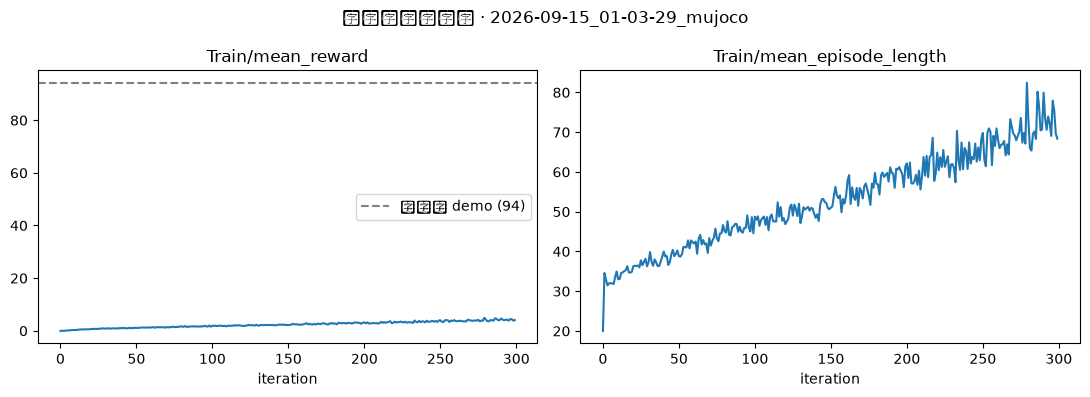

In [8]:
# 阶段三：并排数值 + 阶段一训练曲线
import json
from pathlib import Path

import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

LOG = Path("/workspace/runs/MicroduckVelocityFlat")
DEMO = Path("/workspace/microduck_rl_lab/examples/velocity_flat_demo")

phase1 = sorted(LOG.glob("*_mujoco"), key=lambda p: p.stat().st_mtime)[-1]
s1 = json.loads((phase1 / "run_summary.json").read_text())
s2 = json.loads((DEMO / "run_summary.json").read_text())

print("=" * 50)
print(f"{'':20} {'阶段一 500×300':>16} {'阶段二 2048×500':>16}")
print("=" * 50)
rows = [
    ("num_envs", s1["global_num_envs"], s2["global_num_envs"]),
    ("iterations", s1["completed_iterations"], s2["completed_iterations"]),
    ("total_env_steps", s1["total_env_steps"], s2["total_env_steps"]),
    ("final_reward", f"{s1['final_mean_reward']:.1f}", f"{s2['final_mean_reward']:.1f}"),
    ("episode_length", f"{s1['mean_episode_length']:.0f}", f"{s2['mean_episode_length']:.0f}"),
    ("train_wall_sec", f"{s1['training_wall_time_sec']:.0f}", f"{s2['training_wall_time_sec']:.0f}"),
]
for name, v1, v2 in rows:
    print(f"{name:20} {str(v1):>16} {str(v2):>16}")
print("=" * 50)

def plot_scalars(run_dir: Path, tags: list[str]):
    ev = list(run_dir.glob("events.out.tfevents.*"))
    if not ev:
        return None
    ea = EventAccumulator(str(ev[0]))
    ea.Reload()
    out = {}
    for tag in tags:
        if tag in ea.Tags()["scalars"]:
            s = ea.Scalars(tag)
            out[tag] = ([x.step for x in s], [x.value for x in s])
    return out

tags = ["Train/mean_reward", "Train/mean_episode_length"]
data = plot_scalars(phase1, tags)
if data:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, tag in zip(axes, tags):
        if tag in data:
            xs, ys = data[tag]
            ax.plot(xs, ys)
            if tag == "Train/mean_reward":
                ax.axhline(s2["final_mean_reward"], color="gray", ls="--",
                           label=f"阶段二 demo ({s2['final_mean_reward']:.0f})")
                ax.legend()
        ax.set_title(tag)
        ax.set_xlabel("iteration")
    fig.suptitle(f"阶段一训练曲线 · {phase1.name}")
    plt.tight_layout()
    plt.show()

## J. 小结与术语速查

### 完成检查

| ✓ | 你已经完成 |
|---|---|
| □ | 认识 ROCm、PyTorch、UniLab、MicroDuck 任务包和本 lab 的分工 |
| □ | 理解 RL 交互循环、MDP、策略、奖励和 episode |
| □ | 查看 2-iter 冒烟测试的完整日志 |
| □ | 完成阶段一 500×300 train 和 10 秒 eval |
| □ | 回放阶段二 2048×500 demo |
| □ | 用指标、曲线和视频共同评价策略 |

### 核心结论

- RL 通过仿真试错和奖励反馈学习控制策略，不需要逐状态提供标准关节动作。
- PPO 使用 Actor-Critic，并限制每次策略更新幅度；它稳定、适合连续动作和大规模并行采样，但不代表适用于所有任务。
- 奖励函数定义了“什么叫好”，必须兼顾任务、稳定性、步态、安全与平滑，且要警惕 reward hacking。
- `num_envs` 决定每轮并行数据量，`max_iterations` 决定采样-更新循环次数；训练规模和效果不能只看其中一个数。
- 域随机化提高策略面对不确定性的鲁棒性；curriculum 则逐步改变训练难度，两者概念不同。
- 仿真表现好不等于可直接上真机；仍需模型验证、延迟测试、动作限幅、跌倒保护和急停。

### 术语速查

| 术语 | 一句话解释 |
|---|---|
| Agent | 学习和做决策的主体，本实验中是策略网络 |
| Environment / env | 接收动作并返回下一观测和奖励的仿真世界 |
| Observation | 策略实际可读取的信息，可能带噪声、延迟且不完整 |
| Action | 策略输出给控制系统的命令，本任务为 14 维关节目标 |
| Policy / Actor | 从观测产生动作的模型 |
| Critic / Value | 预测未来累计回报，辅助 Actor 学习 |
| Reward | 每一步的即时反馈；不等于成功率 |
| Return | 从某一步开始的折扣累计奖励 |
| Episode | 从 reset 到摔倒或超时的一段完整交互 |
| Rollout | 用当前策略连续采集的一段 transition |
| Transition | 一条 `(obs, action, reward, next_obs, done)` 数据 |
| Iteration | 一轮“rollout 采样 + PPO 更新” |
| Checkpoint | 某次训练保存的模型参数和相关状态 |
| Domain randomization | 随机改变仿真条件以提升鲁棒性 |
| Curriculum | 随训练进展逐步改变任务或随机化难度 |
| Sim-to-real | 将仿真中学到的策略迁移到真实机器人 |

---

## 附录（选做）：从 demo 续训 +500 iter

在阶段二 demo 基础上再训 **500 iteration**（2048 env，~10 min），观察是否进一步提升：

```bash
cd /opt/microduck_rl_unilab

# 续训（max_iterations=500 表示再跑 500 iter，从 iter ~499 续到 ~999）
bash /workspace/microduck_rl_lab/scripts/run_train.sh \
  --algo ppo --task microduck_velocity_flat --sim mujoco \
  algo.num_envs=2048 algo.max_iterations=500 algo.save_interval=100 \
  algo.load_run=/workspace/microduck_rl_lab/examples/velocity_flat_demo \
  training.no_play=true training.logger=tensorboard training.log_root=/workspace/runs

# 续训后 eval
microduck-eval --algo ppo --task microduck_velocity_flat --sim mujoco \
  --load-run -1 training.play_steps=200 training.log_root=/workspace/runs
```

<details>
<summary>进阶阅读：GAE · PPO clip · mirror loss · curriculum</summary>

- **GAE：** 用多步奖励和 Critic 估计 advantage，在偏差与方差之间折中。
- **PPO clip：** 限制新旧策略概率比带来的优化收益，降低单次更新过大的风险。
- **Mirror loss：** 利用双足机器人的左右对称关系约束策略，减少只偏向一侧的步态。
- **Curriculum：** 按训练进展分阶段修改奖励权重、命令范围或随机化范围；不是简单地“打开全部域随机化”。

</details>

---

## 故障排查

| 现象 | 处理 |
|---|---|
| 训练 cell 长时间 `[*]` | 正常；看 `runs/` 是否出现新目录、`rocm-smi` GPU 是否 busy |
| eval 无 `play_video.mp4` | 确认 `--load-run` 路径含 `model_*.pt` |
| 没有看到机器人画面 | eval 是无窗口离屏渲染；等待当前 cell 完成，日志下方会自动播放内嵌视频 |
| 浏览器阻止自动播放 | 点击视频中央播放按钮；视频已静音并设置为循环播放 |
| `HIP not available` | 确认 compose 映射 `/dev/kfd`、`/dev/dri` |

---

## 下一步：阶段四 · 键盘控制推理

完成训练与视频评估后，打开 [`02_interactive_teleop.ipynb`](02_interactive_teleop.ipynb)：

- 先加载稳定 Demo 验证 teleop 链路，再切换到阶段一生成的 `model_299.pt`；
- 在浏览器 MuJoCo 桌面中只运行一台机器人，并对比两个模型的响应；
- 用 `↑/↓` 控制前后、`←/→` 控制左右横移、`Q/E` 控制转向；
- 验证 61 维观测 → PPO Actor → 14 维关节动作的实时闭环推理。

该阶段验证仿真推理链路，但不等同于真机部署。